In [16]:
from typing import TypedDict, List, Annotated
import operator
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage

In [17]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What do cover")

In [18]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [19]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [20]:
llm = ChatOllama(model="llama3")

In [21]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke([
        SystemMessage(
            content=("Creat a blog plan with 5-7 sections on the following topic.")
        ),
        HumanMessage(content=f"Topic: {state['topic']}")
    ])
    return {"plan": plan}

In [22]:
def fanout(state: State):
    return [Send("worker", {'task': task, "topic": state['topic'], 'plan': state['plan']}) for task in state['plan'].tasks]

In [23]:
def worker(payload: dict) -> dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = llm.invoke([
        SystemMessage(content="Write one clean Markdown section."),
        HumanMessage(
            content=(
                f"Blog Title: {blog_title}\n"
                f"Section Title: {task.title}\n"
                f"Brief: {task.brief}\n"
                f"Topic: {topic}\n"
                "Return only the section content in Markdown format."
            )
        )
    ])
    return {"sections": [section_md.content]}

In [24]:
from pathlib import Path
def reducer(state: State) -> dict:
    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip()
    final_md = f"# {title}\n\n{body}\n"

    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding='utf-8')
    return {"final" : final_md}

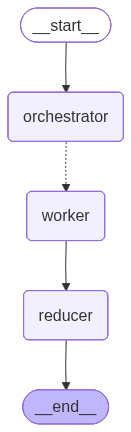

In [25]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [26]:
query = {'topic': "The impact of AI on software development"}
result = app.invoke(query)

In [27]:
result

{'topic': 'The impact of AI on software development',
 'plan': Plan(blog_title='The Impact of AI on Software Development', tasks=[Task(id=1, title='Introduction to AI in Software Development', brief="Provide an overview of what AI is and how it's being used in software development."), Task(id=2, title='Role of Machine Learning in Software Development', brief='Describe the role of machine learning in software development, including automation, data analysis, and prediction.'), Task(id=3, title='Artificial Intelligence-assisted Code Generation', brief='Discuss how AI is being used to generate code, including its benefits and limitations.'), Task(id=4, title='AI-powered Testing and Quality Assurance', brief='Explain how AI can be used for testing and quality assurance in software development, including automated testing and bug detection.'), Task(id=5, title='Human-AI Collaboration in Software Development', brief='Explore the potential benefits of human-AI collaboration in software develo